In [1]:
import json
import pickle
from functools import reduce
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import scipy.stats
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.quantum_info import DensityMatrix, Operator, Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from tqdm.auto import tqdm

In [2]:
def pauli_str_to_unitary(pstr):
    def ch(c):
        return {"I": np.eye(2), "X": np.array([[0, 1], [1, 0]]), "Y": np.array([[0, -1j], [1j, 0]]), "Z": np.diag([1, -1])}[c]
    return reduce(np.kron, [ch(c) for c in pstr], np.array([[1.0]]))

def expect(rho_or_sv, H):
    if rho_or_sv.ndim == 1:
        return float(np.real(rho_or_sv.conj().T @ H @ rho_or_sv))
    return float(np.real(np.trace(rho_or_sv @ H)))

def outer(psi):
    v = psi.reshape(-1, 1)
    return v @ v.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho - sigma))) / 2

def sample_gcauchy(beta, M=1):
    thresh = (1 + np.sqrt(5)) / 2
    cs = []
    while len(cs) < M:
        c = scipy.stats.cauchy.rvs()
        u = scipy.stats.uniform.rvs()
        h = (1 + c**2) / (1 + (c / np.sqrt(2)) ** 4)
        if u < h / thresh:
            cs.append(c)
    return beta * (np.array(cs) if M > 1 else cs[0])

def drop_measured_qubit_dm(rho, ancilla_q: int, ancilla_outcome: int = 0):
    mat = np.asarray(rho.data if isinstance(rho, DensityMatrix) else rho)
    n = int(np.log2(mat.shape[0]))
    axis = n - 1 - ancilla_q
    tens = mat.reshape([2] * n + [2] * n)
    tens_proj = np.take(tens, ancilla_outcome, axis=axis)
    tens_proj = np.take(tens_proj, ancilla_outcome, axis=n + axis - 1)
    mat_proj = tens_proj.reshape(2 ** (n - 1), 2 ** (n - 1))
    p = float(np.real(np.trace(mat_proj)))
    if p > 0:
        mat_proj = mat_proj / p
    return DensityMatrix(mat_proj)

def ite_pauli_gadget(qc, anc, cbit, pauli, gamma_dtau, *, data_qubits=None, postselect_on=0):
    if isinstance(pauli, (list, tuple)):
        pauli = "".join(pauli)
    n = len(pauli)
    data_qubits = list(range(n)) if data_qubits is None else data_qubits
    supp = [i for i, p in enumerate(pauli) if p != "I"]
    if not supp or gamma_dtau == 0:
        return qc
    mag = abs(gamma_dtau)
    for i in supp:
        q = data_qubits[i]
        if pauli[i] == "X":
            qc.h(q)
        elif pauli[i] == "Y":
            qc.sdg(q)
            qc.h(q)
    chain = [data_qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]):
        qc.cx(a, b)
    parity_q = chain[-1]
    if gamma_dtau > 0:
        qc.x(parity_q)
    phi = 2 * np.arccos(np.exp(-2 * mag))
    qc.crx(phi, parity_q, anc)
    qc.measure(anc, cbit)
    qc.reset(anc)
    if gamma_dtau > 0:
        qc.x(parity_q)
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]):
        qc.cx(a, b)
    for i in reversed(supp):
        q = data_qubits[i]
        if pauli[i] == "X":
            qc.h(q)
        elif pauli[i] == "Y":
            qc.h(q)
            qc.s(q)
    return qc

def rte_pauli_gadget(qc, P: str, theta: float, qubits=None):
    n = len(P)
    qubits = list(range(n)) if qubits is None else qubits
    supp = [i for i, p in enumerate(P) if p != "I"]
    if not supp:
        return qc
    for i in supp:
        q = qubits[i]
        if P[i] == "X":
            qc.h(q)
        elif P[i] == "Y":
            qc.sdg(q)
            qc.h(q)
    chain = [qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]):
        qc.cx(a, b)
    qc.rz(2 * theta, chain[-1])
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]):
        qc.cx(a, b)
    for i in reversed(supp):
        q = qubits[i]
        if P[i] == "X":
            qc.h(q)
        elif P[i] == "Y":
            qc.h(q)
            qc.s(q)
    return qc

def trotter_pauli(terms, alpha, *, steps=1, order=2):
    norm = [(t, 1.0) if isinstance(t, str) else (t[0], float(t[1])) for t in terms]

    def S(x, o):
        if o == 1:
            return [(P, x * w) for P, w in norm]
        if o == 2:
            half = x / 2
            fwd = [(P, half * w) for P, w in norm]
            return fwd + list(reversed(fwd))
        p = 1 / (4 - 4 ** (1 / (o - 1)))
        return S(p * x, o - 2) + S((1 - 2 * p) * x, o - 2) + S(p * x, o - 2)

    x = alpha / steps
    return S(x, order) * steps

def spin_chain_H_terms(n, J=1.0, g=1.0):
    Hs = []
    for i in range(n - 1):
        p = list("I" * n)
        p[i] = p[i + 1] = "Z"
        Hs.append(("".join(p), -J))
    for i in range(n):
        p = list("I" * n)
        p[i] = "X"
        Hs.append(("".join(p), -J * g))
    return Hs

def H_to_matrix(Hs, *, qiskit_order=False):
    n = len(Hs[0][0])
    Hm = np.zeros((2**n, 2**n), dtype=complex)
    for t in Hs:
        P, w = (t, 1.0) if isinstance(t, str) else (t[0], float(t[1]))
        lab = "".join(P[::-1]) if not qiskit_order else "".join(P)
        Hm += w * Operator.from_label(lab).data
    return Hm

def make_noise_model(p):
    if p is None or p == 0:
        return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 1), ["x", "h", "s", "sdg", "rz", "rx"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ["cx", "crx"])
    return nm

In [3]:
_root = Path.cwd()
DATA_DIR = (_root if (_root / "noisy.ipynb").exists() else _root / "paper") / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

n = 3
g = 1.4
J = 1.0
betas = np.linspace(1e-3, 1.0, 10)
noise_levels = [0.0, 1e-4, 1e-2]
trotter = (10, 2)
shots = 1000
samples = 10

Hs = spin_chain_H_terms(n, J=J, g=g)
Hmat = H_to_matrix(Hs)
w, V = np.linalg.eigh(Hmat)
ground_state = V[:, 0]
ground_rho = outer(ground_state)

In [4]:
def build_circuit(Hs, n, beta, *, trotter, method):
    sched_ite = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    sched_rte = trotter_pauli(Hs, sample_gcauchy(beta), steps=trotter[0], order=trotter[1]) if method == "r-ite" else []
    main, anc, creg = QuantumRegister(n), QuantumRegister(1), ClassicalRegister(len(sched_ite))
    qc = QuantumCircuit(main, anc, creg)
    for i in range(n):
        qc.h(i)
    for j, (P, c) in enumerate(sched_ite):
        ite_pauli_gadget(qc, anc[0], creg[j], P, gamma_dtau=c)
    for P, c in sched_rte:
        rte_pauli_gadget(qc, P, c)
    qc.save_density_matrix(label="rho", pershot=True)
    return qc

def _extract_postselected_dm(res, tqc, n):
    rhos, mem = res.data(tqc)["rho"], res.get_memory(tqc)
    keep = [k for k, bits in enumerate(mem) if set(bits) <= {"0"}]
    if not keep:
        return None
    dms = [np.asarray(drop_measured_qubit_dm(rhos[k], ancilla_q=n, ancilla_outcome=0).data, dtype=complex) for k in keep]
    return sum(dms) / len(dms)

def _avg_or_zero(raw, D):
    return (sum(raw) / len(raw) if raw else np.zeros((D, D), dtype=complex)), len(raw)

def run_noise_level(Hs, n, betas, *, samples, shots, trotter, noise_model, pbar=None, batch_size=8):
    D, n_beta = 2**n, len(betas)
    raw_r, raw_i, circuits, meta = [[] for _ in range(n_beta)], [[] for _ in range(n_beta)], [], []
    for bi, beta in enumerate(betas):
        for method in ("r-ite", "ite"):
            for _ in range(samples):
                circuits.append(build_circuit(Hs, n, beta, trotter=trotter, method=method))
                meta.append((bi, method))
    sim = AerSimulator(method="density_matrix", noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=1)
    tqcs = transpile(circuits, sim)
    for start in range(0, len(tqcs), batch_size):
        tqc_batch = tqcs[start:start + batch_size]
        res = sim.run(tqc_batch, shots=shots, memory=True).result()
        for j, tqc in enumerate(tqc_batch):
            bi, method = meta[start + j]
            dm = _extract_postselected_dm(res, tqc, n)
            if dm is not None:
                (raw_r if method == "r-ite" else raw_i)[bi].append(dm)
        if pbar is not None:
            pbar.update(len(tqc_batch))
    rho_r = np.zeros((n_beta, D, D), dtype=complex)
    rho_i = np.zeros((n_beta, D, D), dtype=complex)
    kr = np.zeros(n_beta, dtype=np.int32)
    ki = np.zeros(n_beta, dtype=np.int32)
    for bi in range(n_beta):
        rho_r[bi], kr[bi] = _avg_or_zero(raw_r[bi], D)
        rho_i[bi], ki[bi] = _avg_or_zero(raw_i[bi], D)
    return rho_r, rho_i, kr, ki, [{"r_ite": raw_r[bi], "ite": raw_i[bi]} for bi in range(n_beta)]

def sweep_noise(Hs, n, betas, noise_levels, *, trotter, shots, samples, batch_size=8):
    D, n_beta, n_n = 2**n, len(betas), len(noise_levels)
    rho_r = np.zeros((n_n, n_beta, D, D), dtype=complex)
    rho_i = np.zeros((n_n, n_beta, D, D), dtype=complex)
    kr = np.zeros((n_n, n_beta), dtype=np.int32)
    ki = np.zeros((n_n, n_beta), dtype=np.int32)
    raw_store = [[[] for _ in range(n_beta)] for _ in range(n_n)]
    total = len(noise_levels) * len(betas) * 2 * samples
    with tqdm(total=total, desc="noise sweep", unit="run") as pbar:
        for ni, p in enumerate(noise_levels):
            rr, ri, kr_, ki_, raw_ = run_noise_level(Hs, n, betas, samples=samples, shots=shots, trotter=trotter, noise_model=make_noise_model(p if p > 0 else None), pbar=pbar, batch_size=batch_size)
            rho_r[ni], rho_i[ni], kr[ni], ki[ni], raw_store[ni] = rr, ri, kr_, ki_, raw_
    return rho_r, rho_i, kr, ki, raw_store

single pass:   0%|          | 0/200 [00:00<?, ?run/s]

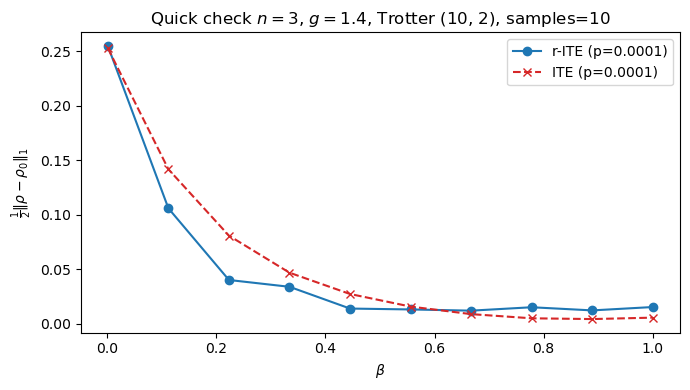

In [5]:
quick_noise = 1e-4
quick_samples = 10
quick_batch_size = 8
with tqdm(total=len(betas) * 2 * quick_samples, desc="single pass", unit="run") as pbar:
    quick_r, quick_i, _, _, _ = run_noise_level(
        Hs, n, betas, samples=quick_samples, shots=shots, trotter=trotter, noise_model=make_noise_model(quick_noise), pbar=pbar, batch_size=quick_batch_size
    )

tr_quick_r = np.array([trdist(rho, ground_rho) for rho in quick_r])
tr_quick_i = np.array([trdist(rho, ground_rho) for rho in quick_i])

plt.figure(figsize=(7, 4))
plt.plot(betas, tr_quick_r, "-o", color="tab:blue", label=rf"r-ITE (p={quick_noise:g})")
plt.plot(betas, tr_quick_i, "--x", color="tab:red", mfc="none", label=rf"ITE (p={quick_noise:g})")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\frac{1}{2}\|\rho-\rho_0\|_1$")
plt.title(f"Quick check $n={n}$, $g={g}$, Trotter {trotter}, samples={quick_samples}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
batch_size = 8
rho_rite, rho_ite, counts_rite, counts_ite, per_beta_samples = sweep_noise(
    Hs, n, betas, noise_levels, trotter=trotter, shots=shots, samples=samples, batch_size=batch_size
)

meta = {
    "n": n,
    "g": g,
    "J": J,
    "trotter_steps": trotter[0],
    "trotter_order": trotter[1],
    "shots": shots,
    "samples_per_beta": samples,
    "noise_levels": noise_levels,
}
stem = DATA_DIR / f"noisy_n{n}_g{g}_J{J}_t{trotter[0]}o{trotter[1]}"
np.savez_compressed(
    stem.with_suffix(".npz"),
    betas=betas,
    noise_levels=np.array(noise_levels),
    rho_rite=rho_rite,
    rho_ite=rho_ite,
    counts_rite=counts_rite,
    counts_ite=counts_ite,
    ground_rho=ground_rho,
    Hmat=Hmat,
)
with open(stem.with_name(stem.name + "_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
with open(stem.with_name(stem.name + "_samples.pkl"), "wb") as f:
    pickle.dump({"per_beta_samples": per_beta_samples, "meta": meta}, f, protocol=pickle.HIGHEST_PROTOCOL)
print("saved", stem.with_suffix(".npz"))

In [ ]:
def trace_distance_curves(rho_rite, rho_ite, ground_rho):
    tr_r = np.array([[trdist(rho_rite[ni, bi], ground_rho) for bi in range(rho_rite.shape[1])] for ni in range(rho_rite.shape[0])])
    tr_i = np.array([[trdist(rho_ite[ni, bi], ground_rho) for bi in range(rho_ite.shape[1])] for ni in range(rho_ite.shape[0])])
    return tr_r, tr_i

tr_r, tr_i = trace_distance_curves(rho_rite, rho_ite, ground_rho)
fig, ax = plt.subplots(figsize=(7, 4))
for ni, p in enumerate(noise_levels):
    c = plt.cm.viridis(ni / max(len(noise_levels) - 1, 1))
    plab = "0" if p == 0 else f"$10^{{{int(np.log10(p))}}}$"
    ax.plot(betas, tr_r[ni], "-o", color=c, label=rf"r-ITE, $p={plab}$")
    ax.plot(betas, tr_i[ni], "--x", color=c, mfc="none", label=rf"ITE, $p={plab}$")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\frac{1}{2}\|\rho - \rho_0\|_1$")
ax.legend(fontsize=8, ncol=2)
ax.set_title(f"TFIM $n={n}$, $g={g}$, Trotter {trotter}")
plt.tight_layout()
plt.show()